# MCD19A2 MODIS Aerosol Optical Depth - Exploratory Data Analysis

This notebook provides comprehensive EDA for the **MCD19A2 MODIS/Terra+Aqua Land Aerosol Optical Depth Daily L2G Global 1km SIN Grid** dataset.

## Dataset Overview

- **Product**: MCD19A2 (MAIAC Land Aerosol Optical Depth)
- **Resolution**: 1 km spatial, daily temporal
- **Format**: HDF4 (Hierarchical Data Format 4)
- **Coverage**: Global, tiled (h00-h35, v00-v17)
- **Key Variables**: AOD at 0.47µm & 0.55µm, AOD uncertainty, water vapor, angles, QA flags

### Key Science Datasets:
1. **Optical_Depth_047** - AOD at 0.47 µm (blue band)
2. **Optical_Depth_055** - AOD at 0.55 µm (green band)
3. **AOD_Uncertainty** - Uncertainty estimates
4. **FineModeFraction** - Fine mode fraction over water
5. **Column_WV** - Column water vapor (cm)
6. **Injection_Height** - Smoke injection height
7. **AOD_QA** - Quality assessment flags
8. Geometric parameters (solar/view angles, azimuth, etc.)

## 1. Setup and Installation

Install required libraries for working with HDF4 files and geospatial data.

In [17]:
# Uncomment to install required packages
# !pip install pyhdf numpy pandas matplotlib seaborn geopandas rasterio pyproj
# !pip install netCDF4 h5py xarray cartopy scipy

## 2. Import Libraries

In [18]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For reading HDF4 files
from pyhdf.SD import SD, SDC

# Optional: for advanced visualizations
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_AVAILABLE = True
except ImportError:
    print("Cartopy not available. Basic plots will be used.")
    CARTOPY_AVAILABLE = False

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 3. File Loading and Metadata Extraction

In [19]:
import os
import glob
import pandas as pd
from datetime import datetime

# Define your data directory
DATA_DIR = '/home/slow_data/Air_Quality/MODIS_MCD19A2'

# Find all MCD19A2 HDF files
# We use path join with wildcards: DATA_DIR / YYYY / day_in_year / filename
# pattern: /home/slow_data/Air_Quality/MODIS_MCD19A2/*/*/MCD19A2*.hdf
search_pattern = os.path.join(DATA_DIR, '*', '*', 'MCD19A2*.hdf')
hdf_files = glob.glob(search_pattern)

# Sort files to ensure order (optional but helpful for display)
hdf_files.sort()

print(f"Found {len(hdf_files)} HDF files in {DATA_DIR}")

if len(hdf_files) > 0:
    print("\nFirst 5 files:")
    for f in hdf_files[:5]:
        # Display relative path to show the structure (Year/Day/File)
        rel_path = os.path.relpath(f, DATA_DIR)
        print(f"  {rel_path}")
else:
    print(f"\nNo files found matching pattern: {search_pattern}")
    print("Please check if the directory structure matches: BASE_DIR/YYYY/DDD/filename.hdf")

Found 2035 HDF files in /home/slow_data/Air_Quality/MODIS_MCD19A2

First 5 files:
  2025/001/MCD19A2.A2025001.h27v06.061.2025003015625.hdf
  2025/001/MCD19A2.A2025001.h27v07.061.2025003063912.hdf
  2025/001/MCD19A2.A2025001.h28v06.061.2025003062750.hdf
  2025/001/MCD19A2.A2025001.h28v07.061.2025003055758.hdf
  2025/001/MCD19A2.A2025001.h28v08.061.2025003054301.hdf


### Parse Filename Information

In [20]:
def parse_mcd19a2_filename(filename):
    """
    Parse MCD19A2 filename to extract metadata.
    Format: MCD19A2.AYYYYDDD.hXXvYY.CCC.YYYYDDDHHMMSS.hdf
    """
    basename = os.path.basename(filename)
    parts = basename.split('.')
    
    # Expected parts length is 6 (including .hdf), but check >= 5 for safety
    if len(parts) >= 5:
        try:
            product = parts[0]
            date_str = parts[1][1:]  # Remove 'A' prefix -> YYYYDDD
            year = int(date_str[:4])
            doy = int(date_str[4:])  # Day of year
            
            tile = parts[2]
            h_tile = int(tile[1:3]) # hHH
            v_tile = int(tile[4:6]) # vVV
            
            collection = parts[3]
            production_time = parts[4] # YYYYDDDHHMMSS
            
            # Convert day of year to date object
            date = datetime.strptime(f"{year}{doy}", "%Y%j")
            
            return {
                'full_path': filename, # Store full path for loading data later
                'filename': basename,
                'product': product,
                'date': date,
                'year': year,
                'doy': doy,
                'tile': tile,
                'h_tile': h_tile,
                'v_tile': v_tile,
                'collection': collection,
                'production_time': production_time
            }
        except ValueError as e:
            print(f"Error parsing {basename}: {e}")
            return None
            
    return None

# Parse all filenames
if len(hdf_files) > 0:
    # Use a list comprehension to process files
    file_metadata = [parse_mcd19a2_filename(f) for f in hdf_files]
    # Filter out any Nones (failed parses)
    file_metadata = [m for m in file_metadata if m is not None]
    
    metadata_df = pd.DataFrame(file_metadata)
    
    print("\n=== File Metadata Summary ===")
    # Adjust pandas display options to see columns clearly
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print(metadata_df[['filename', 'date', 'tile', 'collection']].head(10))
    
    if not metadata_df.empty:
        print(f"\nDate range: {metadata_df['date'].min().date()} to {metadata_df['date'].max().date()}")
        print(f"Total Years: {sorted(metadata_df['year'].unique())}")
        print(f"Unique tiles: {metadata_df['tile'].nunique()} {metadata_df['tile'].unique()}")
        print(f"Collections: {metadata_df['collection'].unique()}")


=== File Metadata Summary ===
                                        filename       date    tile collection
0  MCD19A2.A2025001.h27v06.061.2025003015625.hdf 2025-01-01  h27v06        061
1  MCD19A2.A2025001.h27v07.061.2025003063912.hdf 2025-01-01  h27v07        061
2  MCD19A2.A2025001.h28v06.061.2025003062750.hdf 2025-01-01  h28v06        061
3  MCD19A2.A2025001.h28v07.061.2025003055758.hdf 2025-01-01  h28v07        061
4  MCD19A2.A2025001.h28v08.061.2025003054301.hdf 2025-01-01  h28v08        061
5  MCD19A2.A2025002.h27v06.061.2025003221520.hdf 2025-01-02  h27v06        061
6  MCD19A2.A2025002.h27v07.061.2025004004051.hdf 2025-01-02  h27v07        061
7  MCD19A2.A2025002.h28v06.061.2025003222029.hdf 2025-01-02  h28v06        061
8  MCD19A2.A2025002.h28v07.061.2025003230054.hdf 2025-01-02  h28v07        061
9  MCD19A2.A2025002.h28v08.061.2025003213245.hdf 2025-01-02  h28v08        061

Date range: 2025-01-01 to 2026-02-11
Total Years: [np.int64(2025), np.int64(2026)]
Unique tiles: 5 

## 4. Explore HDF File Structure

In [21]:
# Select a sample file for detailed exploration
if len(hdf_files) > 0:
    sample_file = hdf_files[4]
    print(f"Exploring: {os.path.basename(sample_file)}\n")
    
    # Open the HDF file
    hdf = SD(sample_file, SDC.READ)
    
    # Get list of all datasets
    datasets = hdf.datasets()
    
    print("=== Available Science Datasets ===")
    print(f"Total datasets: {len(datasets)}\n")
    
    # Create a summary dataframe
    dataset_info = []
    for name, info in datasets.items():
        dataset_info.append({
            'Dataset': name,
            'Shape': info[0],
            'Type': info[1],
            'Rank': info[2]
        })
    
    dataset_df = pd.DataFrame(dataset_info)
    print(dataset_df.to_string(index=False))
    
    # Get global attributes
    print("\n=== Global Attributes ===")
    attrs = hdf.attributes()
    for key in list(attrs.keys()):  # Show first 10 attributes
        print(f"{key}: {attrs[key]}")

    # fill_val = attrs['_FillValue']
    # scale_factor = attrs['scale_factor']
    # print(f"\n_FillValue: {fill_val}")
    # print(f"scale_factor: {scale_factor}\n")
    
    hdf.end()

Exploring: MCD19A2.A2025001.h28v08.061.2025003054301.hdf

=== Available Science Datasets ===
Total datasets: 13

            Dataset                                        Shape            Type  Rank
  Optical_Depth_047 (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    22
  Optical_Depth_055 (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    22
    AOD_Uncertainty (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    22
          Column_WV (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    22
AngstromExp_470-780 (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    22
             AOD_QA (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)    23
   FineModeFraction (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)     5
   Injection_Height (Orbits:grid1km, YDim:grid1km, XDim:grid1km) (3, 1200, 1200)     5
             cosSZA (Orbits:grid5km, YDim:grid5km, XDim:grid5km)   (3, 240, 240)    22
             cosV

## 5. Load and Examine Key Variables

In [22]:
def load_sds_with_metadata(hdf_file, sds_name):
    """
    Load a Science Dataset (SDS) with its metadata including scale factor,
    fill value, and valid range.
    """
    hdf = SD(hdf_file, SDC.READ)
    sds = hdf.select(sds_name)
    
    # Get the data
    data = sds.get()
    
    # Get attributes
    attrs = sds.attributes()
    
    # Extract scaling and fill value info
    scale_factor = attrs.get('scale_factor', 1.0)
    add_offset = attrs.get('add_offset', 0.0)
    fill_value = attrs.get('_FillValue', None)
    valid_range = attrs.get('valid_range', None)
    units = attrs.get('units', 'N/A')
    long_name = attrs.get('long_name', sds_name)
    
    sds.endaccess()
    hdf.end()
    
    # Apply scale and offset
    if fill_value is not None:
        data = np.where(data == fill_value, np.nan, data)
    
    data = data * scale_factor + add_offset
    
    metadata = {
        'scale_factor': scale_factor,
        'add_offset': add_offset,
        'fill_value': fill_value,
        'valid_range': valid_range,
        'units': units,
        'long_name': long_name
    }
    
    return data, metadata

# Load key datasets
if len(hdf_files) > 0:
    print("Loading key datasets from sample file...\n")
    
    # Define datasets to load
    key_datasets = [
        'Optical_Depth_047',
        'Optical_Depth_055',
        'AOD_Uncertainty',
        'Column_WV',
        'AOD_QA'
    ]
    
    data_dict = {}
    metadata_dict = {}
    
    for ds_name in key_datasets:
        try:
            data, meta = load_sds_with_metadata(sample_file, ds_name)
            data_dict[ds_name] = data
            metadata_dict[ds_name] = meta
            print(f"✓ Loaded {ds_name}")
            print(f"  Shape: {data.shape}")
            print(f"  Units: {meta['units']}")
            print(f"  Valid data points: {np.sum(~np.isnan(data))}")
            print()
        except Exception as e:
            print(f"✗ Could not load {ds_name}: {e}\n")

Loading key datasets from sample file...

✓ Loaded Optical_Depth_047
  Shape: (3, 1200, 1200)
  Units: N/A
  Valid data points: 82337

✓ Loaded Optical_Depth_055
  Shape: (3, 1200, 1200)
  Units: N/A
  Valid data points: 82337

✓ Loaded AOD_Uncertainty
  Shape: (3, 1200, 1200)
  Units: N/A
  Valid data points: 613994

✓ Loaded Column_WV
  Shape: (3, 1200, 1200)
  Units: N/A
  Valid data points: 2740181

✓ Loaded AOD_QA
  Shape: (3, 1200, 1200)
  Units: N/A
  Valid data points: 3240000



## 6. Basic Statistical Analysis

In [23]:
if len(data_dict) > 0:
    print("=== Statistical Summary ===")
    
    stats_list = []
    for name, data in data_dict.items():
        # Flatten and remove NaNs
        valid_data = data[~np.isnan(data)].flatten()
        
        if len(valid_data) > 0:
            stats = {
                'Variable': name,
                'Mean': np.mean(valid_data),
                'Median': np.median(valid_data),
                'Std': np.std(valid_data),
                'Min': np.min(valid_data),
                'Max': np.max(valid_data),
                'Q25': np.percentile(valid_data, 25),
                'Q75': np.percentile(valid_data, 75),
                'Valid %': (len(valid_data) / data.size) * 100
            }
            stats_list.append(stats)
    
    stats_df = pd.DataFrame(stats_list)
    print(stats_df.to_string(index=False))
    
    # Save statistics
    stats_df.to_csv('mcd19a2_statistics.csv', index=False)
    print("\n✓ Statistics saved to 'mcd19a2_statistics.csv'")

=== Statistical Summary ===
         Variable        Mean    Median         Std     Min       Max       Q25       Q75   Valid %
Optical_Depth_047    0.217070    0.2200    0.079774  0.0000    2.6650    0.1700    0.2610  1.905949
Optical_Depth_055    0.160101    0.1630    0.060330  0.0000    2.0280    0.1230    0.1940  1.905949
  AOD_Uncertainty    0.011714    0.0097    0.014438 -3.1454    2.4311    0.0082    0.0125 14.212824
        Column_WV    2.878434    2.9920    2.197834  0.0530    6.9950    0.3990    5.2000 63.430116
           AOD_QA 2511.998437 1291.0000 1925.524814  1.0000 6249.0000 1288.0000 5387.0000 75.000000

✓ Statistics saved to 'mcd19a2_statistics.csv'


## 7. Data Quality Analysis

In [24]:
if 'AOD_QA' in data_dict:
    qa_data = data_dict['AOD_QA']
    
    print("=== Quality Assessment Analysis ===")
    print(f"QA data shape: {qa_data.shape}")
    print(f"QA data type: {qa_data.dtype}")
    
    # If QA is 3D, take first band for analysis
    if qa_data.ndim == 3:
        qa_2d = qa_data[:, :, 0]
    else:
        qa_2d = qa_data
    
    # Count valid vs invalid pixels
    valid_mask = ~np.isnan(qa_2d)
    print(f"\nValid pixels: {np.sum(valid_mask)} ({np.sum(valid_mask)/qa_2d.size*100:.2f}%)")
    print(f"Invalid/Fill pixels: {np.sum(~valid_mask)} ({np.sum(~valid_mask)/qa_2d.size*100:.2f}%)")
    
    # QA value distribution
    if np.sum(valid_mask) > 0:
        unique_qa, counts = np.unique(qa_2d[valid_mask], return_counts=True)
        print("\nQA Value Distribution (top 10):")
        qa_dist = pd.DataFrame({'QA Value': unique_qa, 'Count': counts, 
                                'Percentage': counts/np.sum(valid_mask)*100})
        print(qa_dist.sort_values('Count', ascending=False).head(10).to_string(index=False))

=== Quality Assessment Analysis ===
QA data shape: (3, 1200, 1200)
QA data type: float64

Valid pixels: 2700 (75.00%)
Invalid/Fill pixels: 900 (25.00%)

QA Value Distribution (top 10):
 QA Value  Count  Percentage
   1283.0    854   31.629630
   1291.0    642   23.777778
   5387.0    539   19.962963
   1280.0    409   15.148148
   1288.0     68    2.518519
      1.0     44    1.629630
   6153.0     37    1.370370
   1057.0     23    0.851852
   5385.0     22    0.814815
   1290.0     13    0.481481


## 8. Spatial Visualization

Data is in (Orbit, Row, Column)

In the context of MODIS MCD19A2 HDF files, the data is stored as a 3D "Cube." Here is what the three dimensions represent:

### 1. Rows and Columns (The Map)

These represent the **spatial** location (Latitude and Longitude) on the Earth's surface.

* **Rows (Height/Y-axis):** Lines of pixels running from North to South.
* **Columns (Width/X-axis):** Lines of pixels running from West to East.

For a standard MAIAC (MCD19A2) tile, the grid is typically **1200 x 1200 pixels**. Each pixel represents a 1km square on the ground.

### 2. Orbits (The Time Layers)

This is the "depth" or 3rd dimension of the cube. It represents **different satellite overpasses** (snapshots) that happened on that specific day.

Because the satellites (Terra and Aqua) orbit the Earth continuously, they might fly over your specific location (tile) more than once in a single day.

* **Index 0:** The 1st time the satellite passed over this tile (e.g., 10:30 AM).
* **Index 1:** The 2nd time the satellite passed over this tile (e.g., 12:15 PM).
* **Index 2+:** Empty slots (fill values) if the satellite didn't pass a 3rd time.

### Visual Analogy

Think of the 3D array `(4, 1200, 1200)` as a **stack of 4 transparent papers**:

* **Paper 1 (Orbit 0):** Has a drawing of the pollution (AOD) from the morning pass.
* **Paper 2 (Orbit 1):** Has a drawing of the pollution from the afternoon pass.
* **Paper 3 & 4:** Are likely blank (fill values) because the satellite didn't pass again.

### Why your previous plot was blank

When you did `data[:, :, 0]`, you effectively took a pair of scissors and cut a **thin vertical slice** through the entire stack of papers. You got a cross-section of the time layers, not a map of the ground.

When you do `data[0, :, :]`, you are picking up the **top sheet of paper** (the first orbit) to look at the map on it.

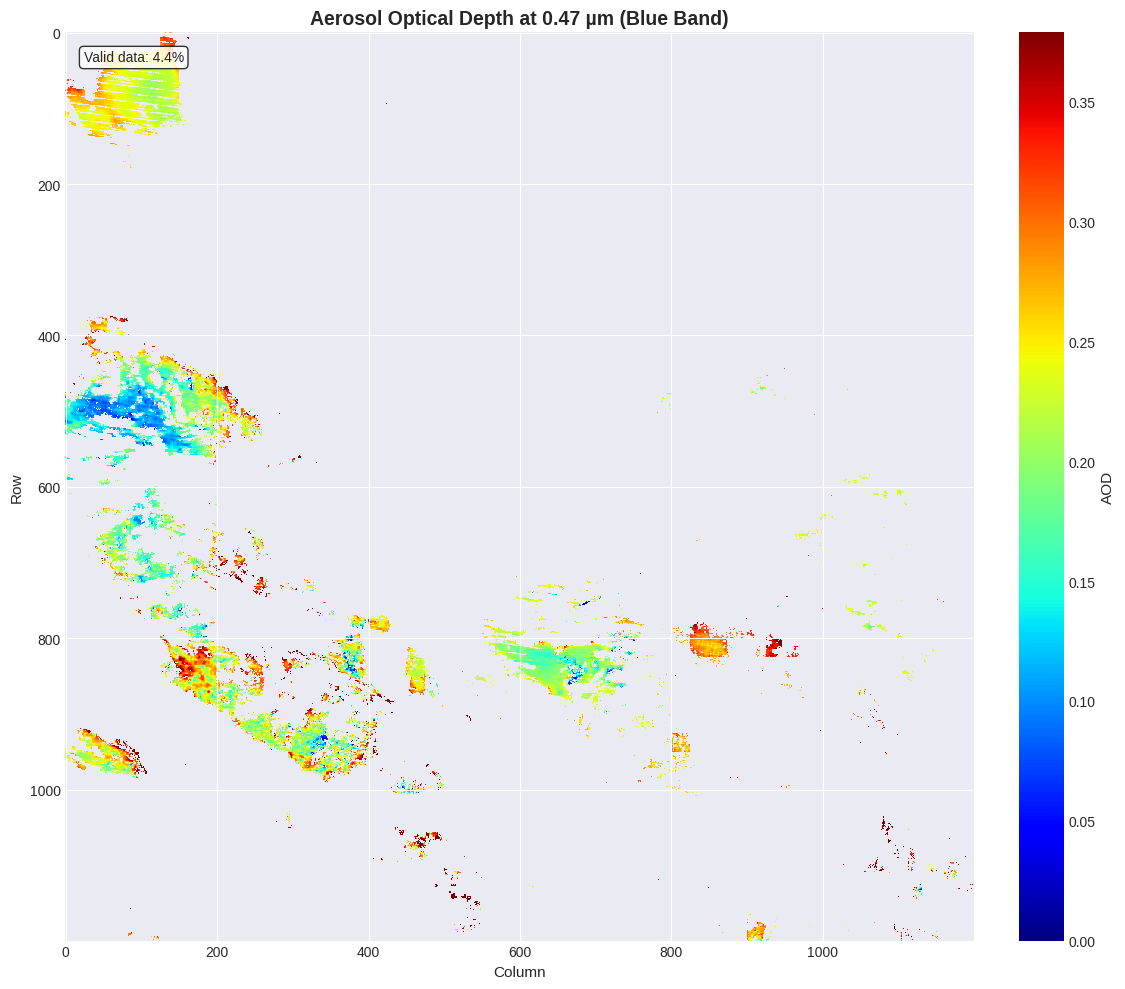

✓ Saved: aod_047_spatial.png


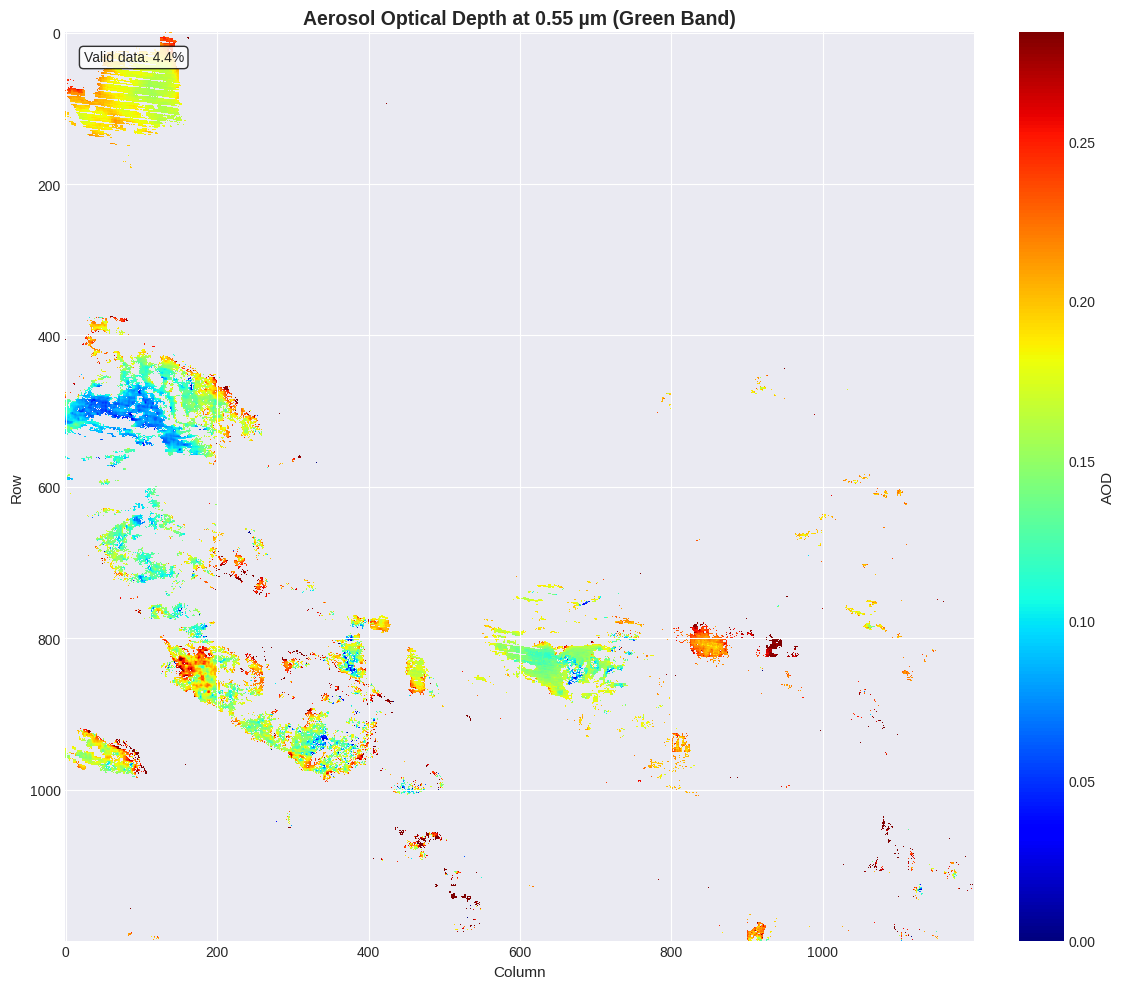

✓ Saved: aod_055_spatial.png


In [ ]:
def plot_aod_spatial(data, title, cmap='jet'):
    """
    Create a spatial plot of AOD data.
    """
    # If 3D, take first band
    if data.ndim == 3:
        data_2d = data[0, :, :]
    else:
        data_2d = data

    # Determine common color scale (ignoring outliers for better contrast)
    all_valid_values = data_2d.flatten()
    all_valid_values = all_valid_values[~np.isnan(all_valid_values)]

    vmin = np.nanmin(all_valid_values)
    vmax = np.nanpercentile(all_valid_values, 98) # 98th percentile to ignore hotspots
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    im = ax.imshow(data_2d, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Column', fontsize=11)
    ax.set_ylabel('Row', fontsize=11)
    
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('AOD', fontsize=11)
    
    # Add data coverage info
    valid_pct = np.sum(~np.isnan(data_2d)) / data_2d.size * 100
    ax.text(0.02, 0.98, f'Valid data: {valid_pct:.1f}%', 
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig

# Plot AOD at 0.47 µm
if 'Optical_Depth_047' in data_dict:
    fig = plot_aod_spatial(data_dict['Optical_Depth_047'], 
                          'Aerosol Optical Depth at 0.47 µm (Blue Band)',
                          )
    plt.savefig('aod_047_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: aod_047_spatial.png")

# Plot AOD at 0.55 µm
if 'Optical_Depth_055' in data_dict:
    fig = plot_aod_spatial(data_dict['Optical_Depth_055'], 
                          'Aerosol Optical Depth at 0.55 µm (Green Band)',
                          )
    plt.savefig('aod_055_spatial.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: aod_055_spatial.png")

## Temporal (in 1 day)


Analyzing 3 orbits for: Optical_Depth_047
  Orbit 0: [VALID] Mean: 0.223 | Max: 0.595 | Cov: 4.4%
  Orbit 1: [VALID] Mean: 0.224 | Max: 2.665 | Cov: 0.9%
  Orbit 2: [VALID] Mean: 0.125 | Max: 0.449 | Cov: 0.4%
Plotting range: 0.000 to 0.394


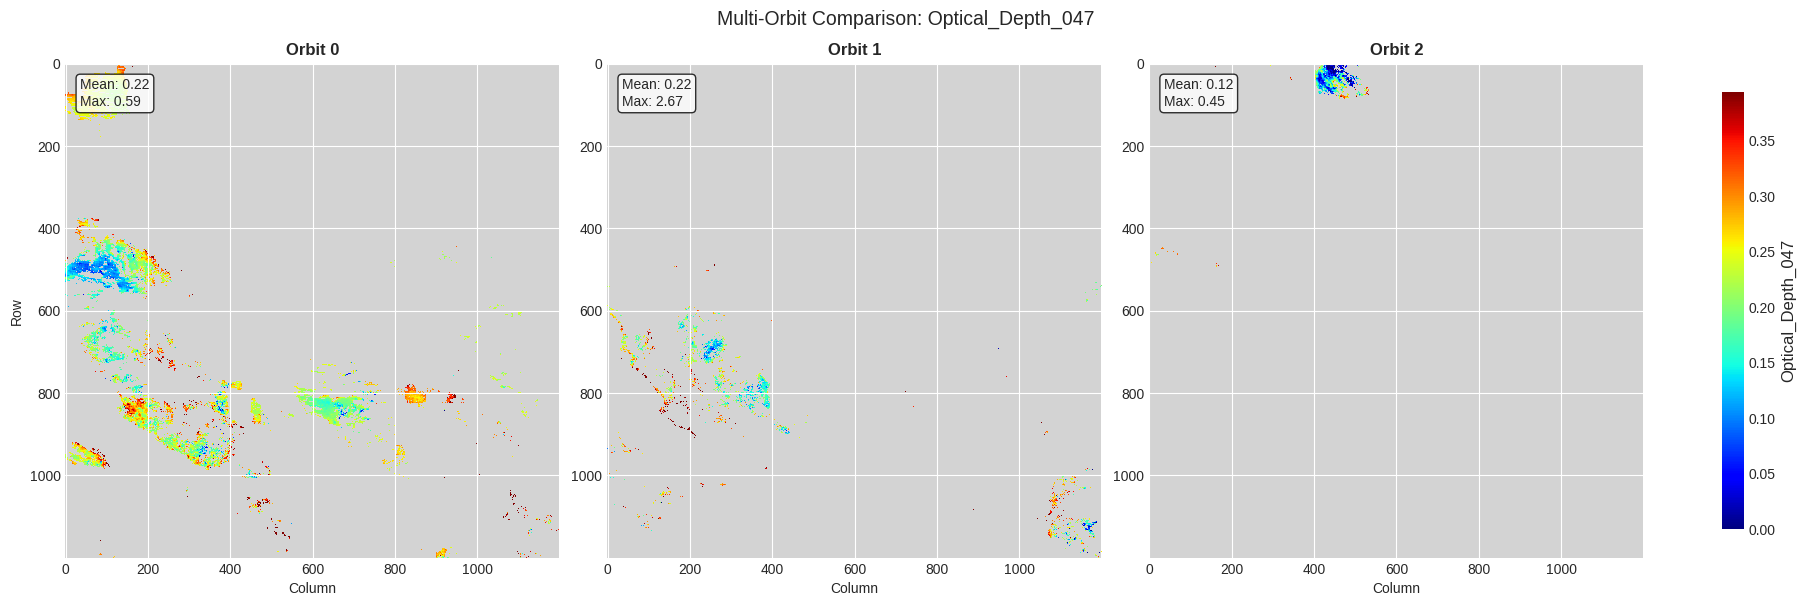


=== Orbit Statistics Summary ===
 Orbit   Mean   Max  Min  Coverage_%
     0 0.2233 0.595  0.0      4.4347
     1 0.2239 2.665  0.0      0.9161
     2 0.1247 0.449  0.0      0.3670

Analyzing 3 orbits for: Optical_Depth_055
  Orbit 0: [VALID] Mean: 0.166 | Max: 0.589 | Cov: 4.4%
  Orbit 1: [VALID] Mean: 0.162 | Max: 2.028 | Cov: 0.9%
  Orbit 2: [VALID] Mean: 0.090 | Max: 0.326 | Cov: 0.4%
Plotting range: 0.000 to 0.290


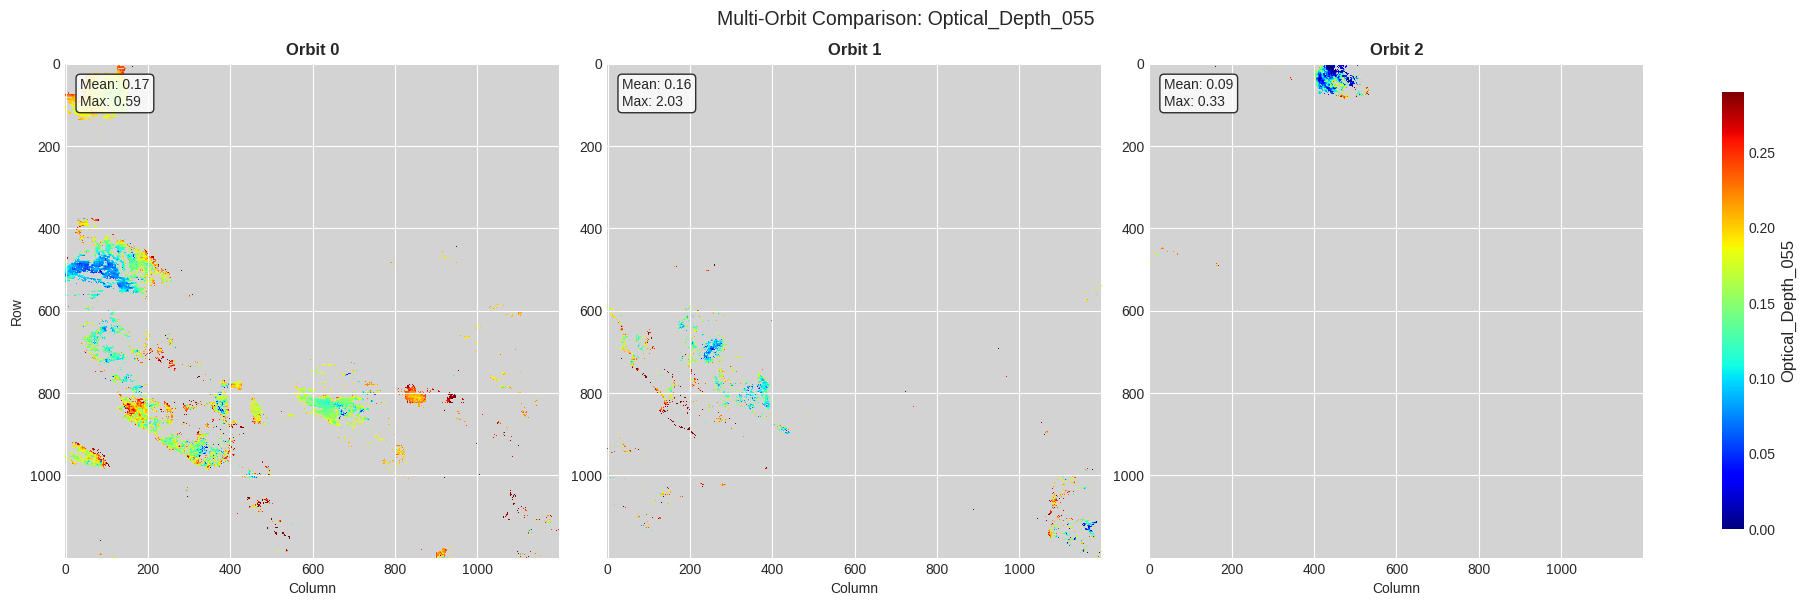


=== Orbit Statistics Summary ===
 Orbit   Mean   Max  Min  Coverage_%
     0 0.1656 0.589  0.0      4.4347
     1 0.1617 2.028  0.0      0.9161
     2 0.0896 0.326  0.0      0.3670


In [26]:
def analyze_orbits_from_data(data, dataset_name):
    """
    Analyzes specific orbits (time layers) from pre-loaded 3D data.
    """
    # 1. Check if data is 3D
    if data.ndim != 3:
        print(f"Skipping orbit analysis: '{dataset_name}' is not 3D (Shape: {data.shape})")
        return

    num_orbits = data.shape[0]
    print(f"\nAnalyzing {num_orbits} orbits for: {dataset_name}")

    valid_orbits = []
    stats_list = []

    # 2. Iterate through each orbit
    for i in range(num_orbits):
        # Extract the 2D layer (already scaled and NaN-filled by your loader)
        layer = data[i, :, :]
        
        # Check for valid pixels (pixels that are NOT NaN)
        valid_pixels_count = np.sum(~np.isnan(layer))
        
        if valid_pixels_count == 0:
            print(f"  Orbit {i}: [EMPTY] All NaN/Fill values.")
            continue
            
        # Calculate stats
        mean_val = np.nanmean(layer)
        max_val = np.nanmax(layer)
        total_pixels = layer.size
        coverage = (valid_pixels_count / total_pixels) * 100
        
        valid_orbits.append((i, layer))
        
        stats_list.append({
            'Orbit': i,
            'Mean': mean_val,
            'Max': max_val,
            'Min': np.nanmin(layer),
            'Coverage_%': coverage
        })
        print(f"  Orbit {i}: [VALID] Mean: {mean_val:.3f} | Max: {max_val:.3f} | Cov: {coverage:.1f}%")

    # 3. Visualize if valid orbits exist
    if not valid_orbits:
        print("No valid data found in any orbit.")
        return

    # Dynamic subplot layout
    num_valid = len(valid_orbits)
    fig, axes = plt.subplots(1, num_valid, figsize=(6 * num_valid, 6), constrained_layout=True)
    
    if num_valid == 1:
        axes = [axes]

    # Determine common color scale (ignoring outliers for better contrast)
    all_valid_values = np.concatenate([v[1].flatten() for v in valid_orbits])
    all_valid_values = all_valid_values[~np.isnan(all_valid_values)]
    
    vmin = np.nanmin(all_valid_values)
    vmax = np.nanpercentile(all_valid_values, 98) # 98th percentile to ignore hotspots
    
    print(f"Plotting range: {vmin:.3f} to {vmax:.3f}")

    for ax, (orbit_idx, layer_data) in zip(axes, valid_orbits):
        # Set background to grey for NaNs
        ax.set_facecolor('#d3d3d3')
        
        im = ax.imshow(layer_data, cmap='jet', vmin=vmin, vmax=vmax, interpolation='nearest')
        
        ax.set_title(f"Orbit {orbit_idx}", fontsize=12, fontweight='bold')
        ax.set_xlabel('Column')
        if ax == axes[0]:
            ax.set_ylabel('Row')
            
        # Add stats box
        stats = next(s for s in stats_list if s["Orbit"] == orbit_idx)
        stats_text = f"Mean: {stats['Mean']:.2f}\nMax: {stats['Max']:.2f}"
        ax.text(0.03, 0.97, stats_text, transform=ax.transAxes, 
                va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Single colorbar
    cbar = fig.colorbar(im, ax=axes, location='right', shrink=0.8)
    cbar.set_label(f'{dataset_name}', fontsize=12)
    
    plt.suptitle(f"Multi-Orbit Comparison: {dataset_name}", fontsize=14)
    plt.show()
    
    # 4. Print Summary Table
    print("\n=== Orbit Statistics Summary ===")
    print(pd.DataFrame(stats_list).round(4).to_string(index=False))


if 'Optical_Depth_047' in data_dict:
    analyze_orbits_from_data(data_dict['Optical_Depth_047'], 'Optical_Depth_047')
if 'Optical_Depth_055' in data_dict:
    analyze_orbits_from_data(data_dict['Optical_Depth_055'], 'Optical_Depth_055')

## 9. Distribution Analysis

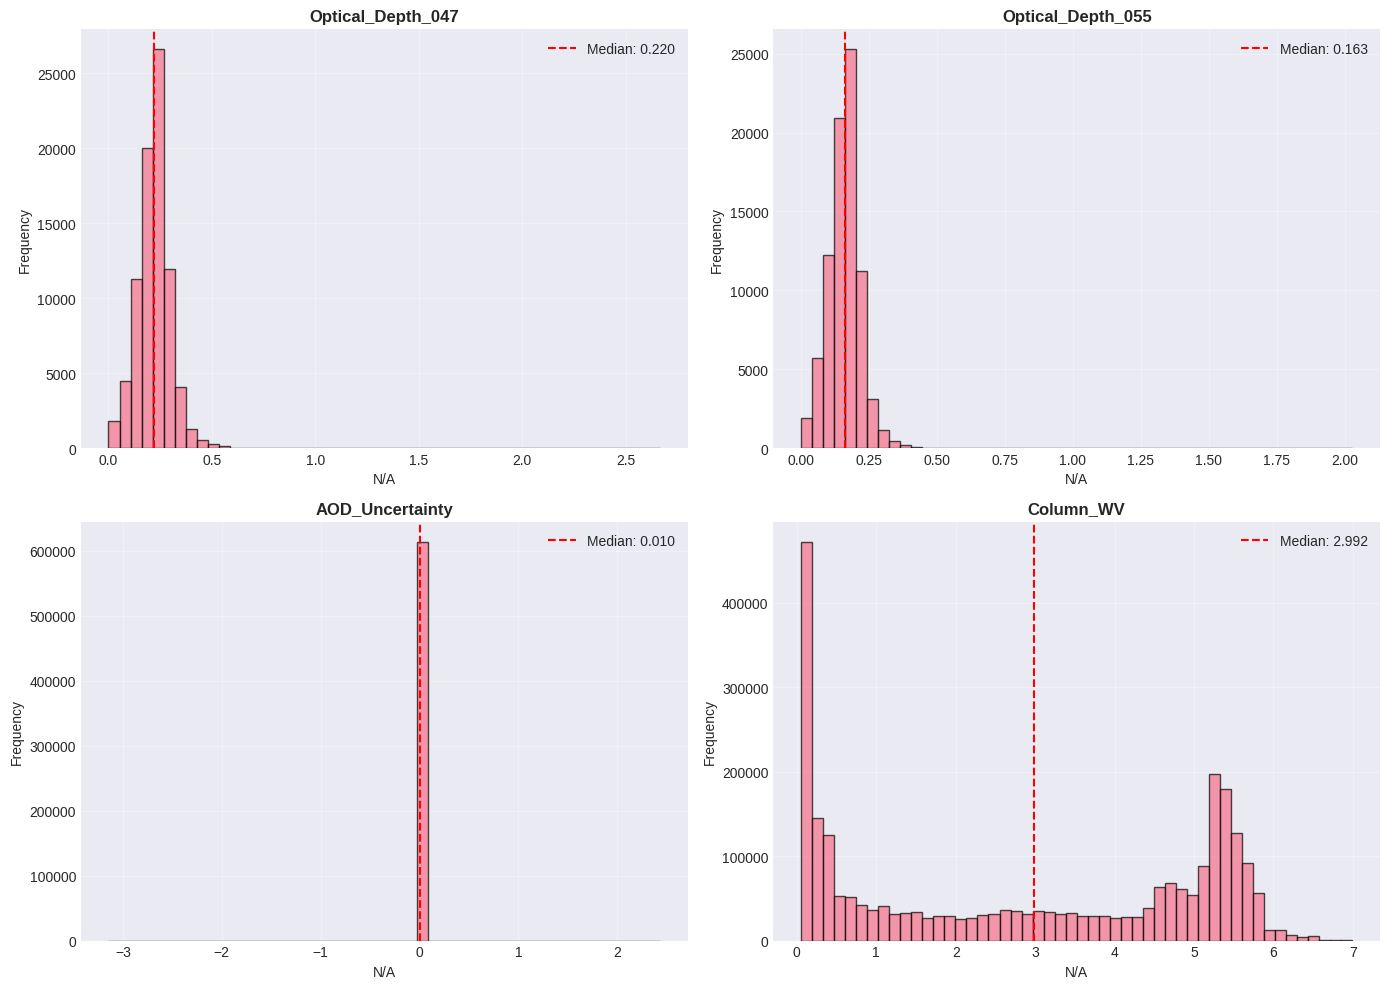

✓ Saved: distributions.png


In [27]:
if len(data_dict) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    plot_vars = ['Optical_Depth_047', 'Optical_Depth_055', 
                 'AOD_Uncertainty', 'Column_WV']
    
    for idx, var_name in enumerate(plot_vars):
        if var_name in data_dict and idx < len(axes):
            data = data_dict[var_name]
            valid_data = data[~np.isnan(data)].flatten()
            
            if len(valid_data) > 0:
                axes[idx].hist(valid_data, bins=50, edgecolor='black', alpha=0.7)
                axes[idx].set_title(var_name, fontweight='bold')
                axes[idx].set_xlabel(f'{metadata_dict[var_name]["units"]}')
                axes[idx].set_ylabel('Frequency')
                axes[idx].axvline(np.median(valid_data), color='red', 
                                linestyle='--', label=f'Median: {np.median(valid_data):.3f}')
                axes[idx].legend()
                axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: distributions.png")

## 10. AOD Comparison (0.47 µm vs 0.55 µm)

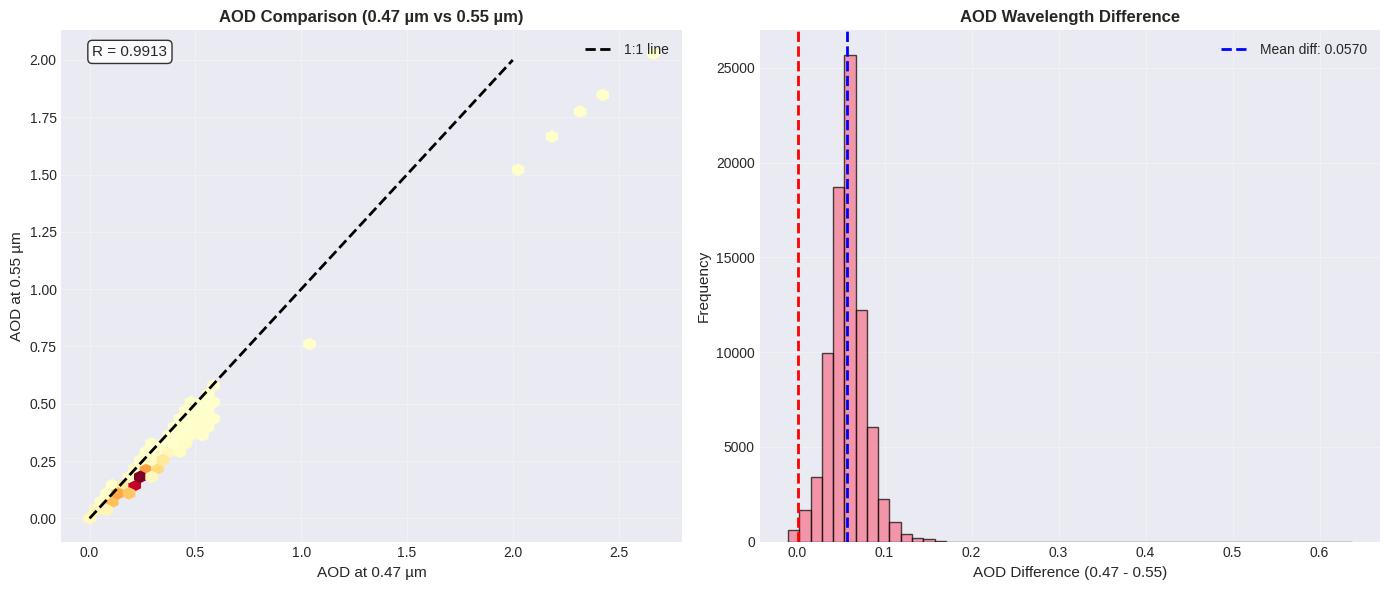

✓ Saved: aod_comparison.png

Correlation: 0.9913
Mean difference: 0.0570
Std difference: 0.0215


In [28]:
if 'Optical_Depth_047' in data_dict and 'Optical_Depth_055' in data_dict:
    aod_047 = data_dict['Optical_Depth_047']
    aod_055 = data_dict['Optical_Depth_055']
    
    # Flatten and get valid pairs
    aod_047_flat = aod_047.flatten()
    aod_055_flat = aod_055.flatten()
    
    # Create mask for valid data in both
    valid_mask = ~np.isnan(aod_047_flat) & ~np.isnan(aod_055_flat)
    aod_047_valid = aod_047_flat[valid_mask]
    aod_055_valid = aod_055_flat[valid_mask]
    
    if len(aod_047_valid) > 0:
        # Scatter plot
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Density scatter
        axes[0].hexbin(aod_047_valid, aod_055_valid, gridsize=50, 
                      cmap='YlOrRd', mincnt=1)
        axes[0].plot([0, 2], [0, 2], 'k--', lw=2, label='1:1 line')
        axes[0].set_xlabel('AOD at 0.47 µm', fontsize=11)
        axes[0].set_ylabel('AOD at 0.55 µm', fontsize=11)
        axes[0].set_title('AOD Comparison (0.47 µm vs 0.55 µm)', fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Correlation
        correlation = np.corrcoef(aod_047_valid, aod_055_valid)[0, 1]
        axes[0].text(0.05, 0.95, f'R = {correlation:.4f}', 
                    transform=axes[0].transAxes, fontsize=11,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        # Difference plot
        diff = aod_047_valid - aod_055_valid
        axes[1].hist(diff, bins=50, edgecolor='black', alpha=0.7)
        axes[1].axvline(0, color='red', linestyle='--', lw=2)
        axes[1].axvline(np.mean(diff), color='blue', linestyle='--', 
                       lw=2, label=f'Mean diff: {np.mean(diff):.4f}')
        axes[1].set_xlabel('AOD Difference (0.47 - 0.55)', fontsize=11)
        axes[1].set_ylabel('Frequency', fontsize=11)
        axes[1].set_title('AOD Wavelength Difference', fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('aod_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Saved: aod_comparison.png")
        print(f"\nCorrelation: {correlation:.4f}")
        print(f"Mean difference: {np.mean(diff):.4f}")
        print(f"Std difference: {np.std(diff):.4f}")

## 11. Spatial Coverage Analysis

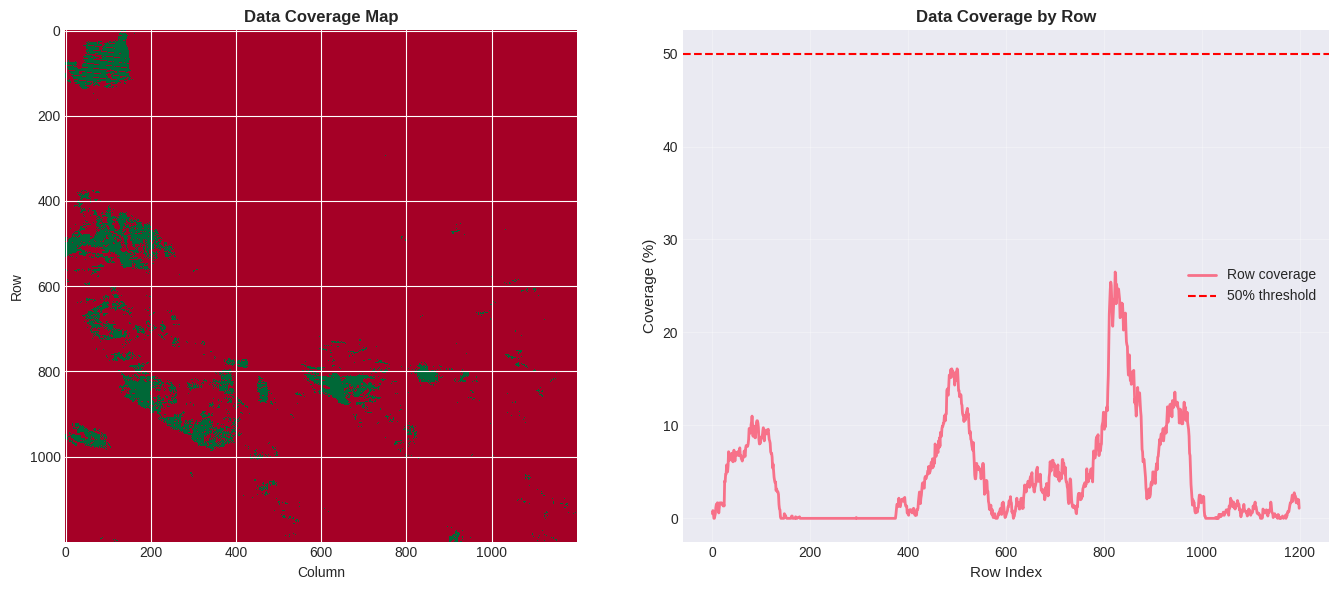

✓ Saved: coverage_analysis.png

Total data coverage: 4.43%


In [32]:
if 'Optical_Depth_055' in data_dict:
    aod = data_dict['Optical_Depth_055']
    
    # Create coverage map (1 = valid, 0 = missing)
    if aod.ndim == 3:
        coverage = ~np.isnan(aod[0, :, :])
    else:
        coverage = ~np.isnan(aod)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Coverage map
    axes[0].imshow(coverage, cmap='RdYlGn', interpolation='nearest')
    axes[0].set_title('Data Coverage Map', fontweight='bold')
    axes[0].set_xlabel('Column')
    axes[0].set_ylabel('Row')
    
    # Coverage by row/column
    row_coverage = np.sum(coverage, axis=1) / coverage.shape[1] * 100
    col_coverage = np.sum(coverage, axis=0) / coverage.shape[0] * 100
    
    axes[1].plot(row_coverage, label='Row coverage', linewidth=2)
    axes[1].axhline(50, color='red', linestyle='--', label='50% threshold')
    axes[1].set_xlabel('Row Index', fontsize=11)
    axes[1].set_ylabel('Coverage (%)', fontsize=11)
    axes[1].set_title('Data Coverage by Row', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('coverage_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: coverage_analysis.png")
    
    total_coverage = np.sum(coverage) / coverage.size * 100
    print(f"\nTotal data coverage: {total_coverage:.2f}%")

## 12. Temporal Analysis (if multiple files available)

=== Temporal Analysis ===
Analyzing 2035 files...

Error processing MCD19A2.A2025001.h28v06.061.2025003062750.hdf: SD (7): Error opening file


Error processing MCD19A2.A2025005.h27v06.061.2025006171336.hdf: SD (10): Read error
Error processing MCD19A2.A2025005.h28v06.061.2025006190416.hdf: SD (10): Read error


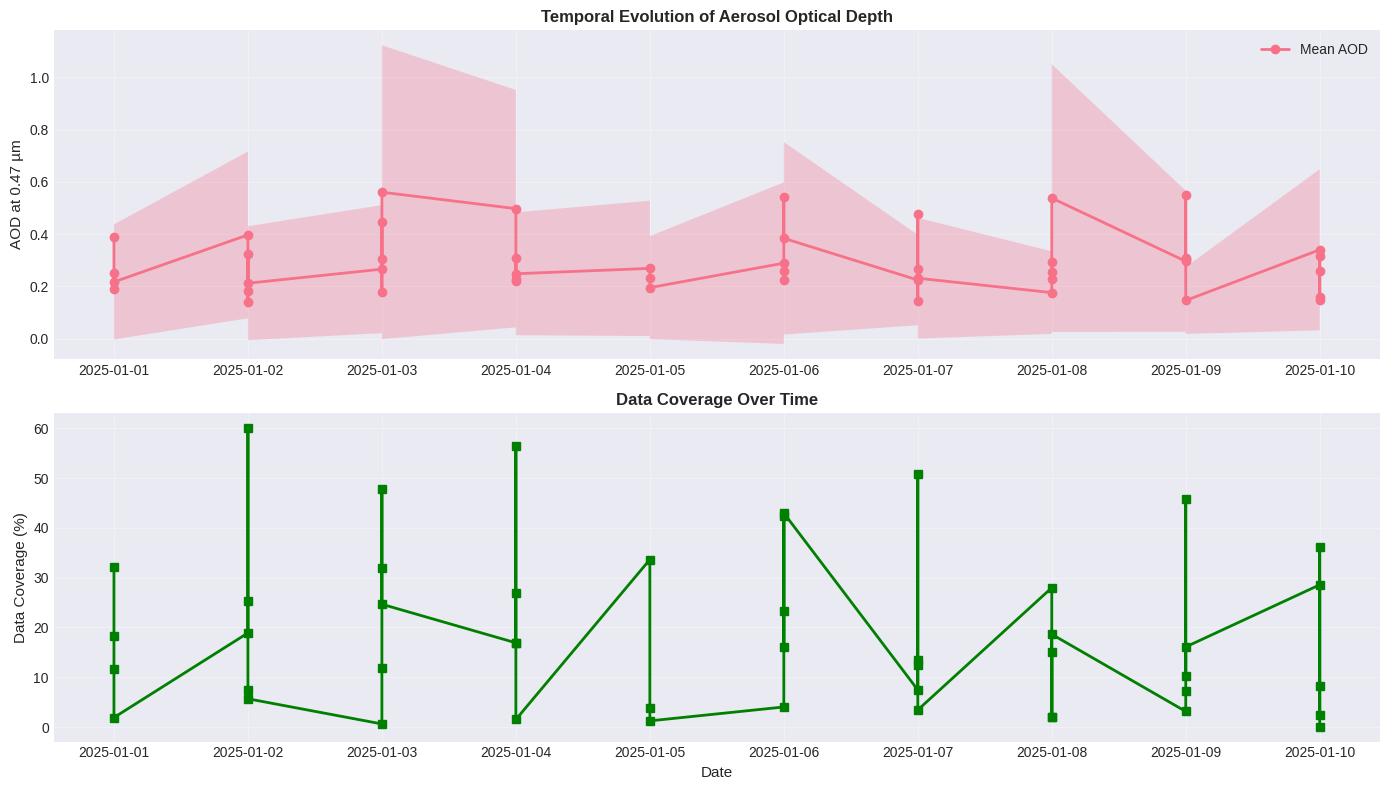

✓ Saved: temporal_analysis.png
✓ Saved: temporal_statistics.csv


In [30]:
if len(hdf_files) > 1:
    print("=== Temporal Analysis ===")
    print(f"Analyzing {len(hdf_files)} files...\n")
    
    # Load AOD from all files
    temporal_data = []
    
    for idx, file in enumerate(hdf_files[:50]):  # Limit to first 50 for speed
        try:
            data, _ = load_sds_with_metadata(file, 'Optical_Depth_047')
            metadata = parse_mcd19a2_filename(file)
            
            # Calculate statistics
            valid_data = data[~np.isnan(data)]
            if len(valid_data) > 0:
                temporal_data.append({
                    'date': metadata['date'],
                    'mean_aod': np.mean(valid_data),
                    'median_aod': np.median(valid_data),
                    'max_aod': np.max(valid_data),
                    'coverage': len(valid_data) / data.size * 100
                })
        except Exception as e:
            print(f"Error processing {os.path.basename(file)}: {e}")
    
    if len(temporal_data) > 0:
        temporal_df = pd.DataFrame(temporal_data).sort_values('date')
        
        # Plot time series
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        
        # AOD time series
        axes[0].plot(temporal_df['date'], temporal_df['mean_aod'], 
                    marker='o', label='Mean AOD', linewidth=2)
        axes[0].fill_between(temporal_df['date'], 
                            temporal_df['mean_aod'] - temporal_df['median_aod'],
                            temporal_df['mean_aod'] + temporal_df['median_aod'],
                            alpha=0.3)
        axes[0].set_ylabel('AOD at 0.47 µm', fontsize=11)
        axes[0].set_title('Temporal Evolution of Aerosol Optical Depth', fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Coverage time series
        axes[1].plot(temporal_df['date'], temporal_df['coverage'], 
                    marker='s', color='green', linewidth=2)
        axes[1].set_xlabel('Date', fontsize=11)
        axes[1].set_ylabel('Data Coverage (%)', fontsize=11)
        axes[1].set_title('Data Coverage Over Time', fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("✓ Saved: temporal_analysis.png")
        
        # Save temporal data
        temporal_df.to_csv('temporal_statistics.csv', index=False)
        print("✓ Saved: temporal_statistics.csv")
else:
    print("Not enough files for temporal analysis (need at least 2 files)")

Each timestamp have 5 points indicate 5 tiles

## 13. Summary Report

In [31]:
print("="*60)
print("MCD19A2 EXPLORATORY DATA ANALYSIS - SUMMARY REPORT")
print("="*60)

if len(hdf_files) > 0:
    print(f"\n📁 Files Analyzed: {len(hdf_files)}")
    print(f"📅 Date Range: {metadata_df['date'].min()} to {metadata_df['date'].max()}")
    print(f"🗺️  Unique Tiles: {metadata_df['tile'].nunique()}")
    print(f"📦 Collections: {', '.join(metadata_df['collection'].unique())}")
    
    if len(data_dict) > 0:
        print("\n📊 Key Findings:")
        
        if 'Optical_Depth_047' in data_dict:
            aod = data_dict['Optical_Depth_047'][~np.isnan(data_dict['Optical_Depth_047'])]
            print(f"   • Mean AOD (0.47 µm): {np.mean(aod):.4f}")
            print(f"   • Median AOD (0.47 µm): {np.median(aod):.4f}")
            print(f"   • AOD Range: {np.min(aod):.4f} - {np.max(aod):.4f}")
        
        if 'Column_WV' in data_dict:
            wv = data_dict['Column_WV'][~np.isnan(data_dict['Column_WV'])]
            print(f"   • Mean Water Vapor: {np.mean(wv):.2f} cm")
        
        # Data quality
        coverage = np.sum(~np.isnan(data_dict['Optical_Depth_047'])) / data_dict['Optical_Depth_047'].size * 100
        print(f"   • Data Coverage: {coverage:.2f}%")
        
    print("\n📈 Generated Outputs:")
    outputs = ['aod_047_spatial.png', 'aod_055_spatial.png', 'distributions.png',
               'aod_comparison.png', 'coverage_analysis.png', 
               'mcd19a2_statistics.csv']
    for output in outputs:
        if os.path.exists(output):
            print(f"   ✓ {output}")
    
    print("\n💡 Recommendations:")
    print("   • Apply QA filtering for high-quality retrievals")
    print("   • Consider cloud screening thresholds")
    print("   • Analyze seasonal patterns if temporal data available")
    print("   • Validate against ground-based measurements if available")
    print("   • Consider geometric correction for viewing angles")
    
else:
    print("\n⚠️  No HDF files found. Please update DATA_DIR path.")
    print("\nTo get started:")
    print("   1. Download MCD19A2 data from https://ladsweb.modaps.eosdis.nasa.gov/")
    print("   2. Place HDF files in a directory")
    print("   3. Update DATA_DIR variable in cell 3")
    print("   4. Rerun the notebook")

print("\n" + "="*60)
print("Analysis complete! 🎉")
print("="*60)

MCD19A2 EXPLORATORY DATA ANALYSIS - SUMMARY REPORT

📁 Files Analyzed: 2035
📅 Date Range: 2025-01-01 00:00:00 to 2026-02-11 00:00:00
🗺️  Unique Tiles: 5
📦 Collections: 061

📊 Key Findings:
   • Mean AOD (0.47 µm): 0.2171
   • Median AOD (0.47 µm): 0.2200
   • AOD Range: 0.0000 - 2.6650
   • Mean Water Vapor: 2.88 cm
   • Data Coverage: 1.91%

📈 Generated Outputs:
   ✓ aod_047_spatial.png
   ✓ aod_055_spatial.png
   ✓ distributions.png
   ✓ aod_comparison.png
   ✓ coverage_analysis.png
   ✓ mcd19a2_statistics.csv

💡 Recommendations:
   • Apply QA filtering for high-quality retrievals
   • Consider cloud screening thresholds
   • Analyze seasonal patterns if temporal data available
   • Validate against ground-based measurements if available
   • Consider geometric correction for viewing angles

Analysis complete! 🎉


## 14. Additional Resources

### Documentation
- [MCD19A2 User Guide](https://lpdaac.usgs.gov/documents/110/MCD19_User_Guide_V6.pdf)
- [MAIAC ATBD](https://lpdaac.usgs.gov/documents/119/MCD19_ATBD.pdf)
- [NASA Earthdata](https://www.earthdata.nasa.gov/)

### Data Access
- [LAADS DAAC](https://ladsweb.modaps.eosdis.nasa.gov/)
- [NASA Earthdata Search](https://search.earthdata.nasa.gov/)
- [Google Earth Engine](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES)

### Key References
1. Lyapustin, A., et al. (2018). MODIS Collection 6 MAIAC algorithm. 
   *Atmospheric Measurement Techniques*, 11, 5741-5765.
2. Wang, Y., et al. (2022). Global estimates of air quality changes from MODIS MAIAC.

---

**Notebook Created:** February 2026  
**Dataset:** MCD19A2 V061  
**Contact:** NASA LP DAAC - https://lpdaac.usgs.gov/  